In [4]:
# PHYS 311
# LAB 5 - ORBITAL MECHANICS SIMULATOR
# Alexander Berry
# September 22, 2026

# IMPORT TOOLS

import numpy as np
import matplotlib.pyplot as plt

# SIMULATION CONSTANTS

G = 1.0
M = 1.0 
m = 1.0

## Part A - Single Orbit with Velocity Verlet

In this part, we model the motion of a planet orbiting a fixed central star using Newton's law of universal gravitation as well as the Velocity Verlet integration method.

Furthermore, we define the gravitational acceleration and implement the Velocity integrator. We then plot the orbital trajectory and track the total mechanical energy and the angular momentum vs. time, and evaluate the accuracy/stability of the simulation.

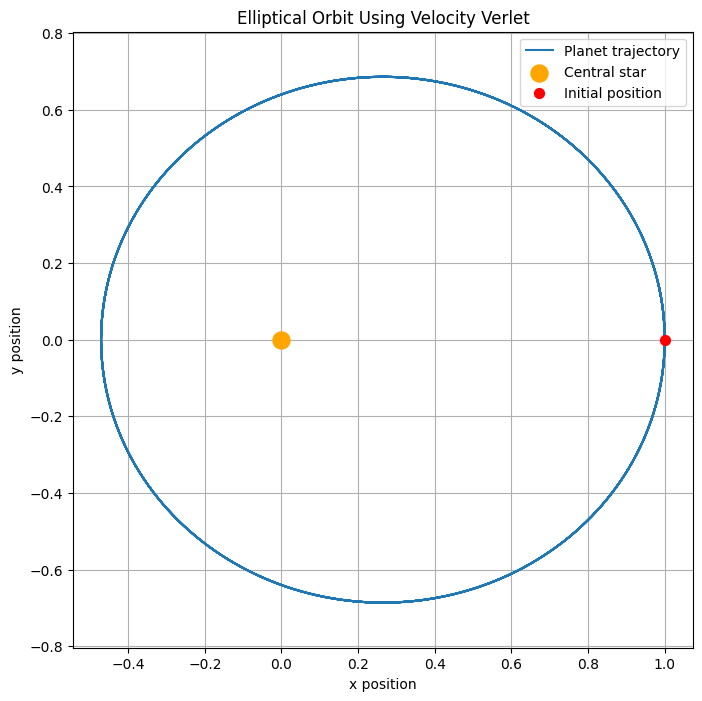

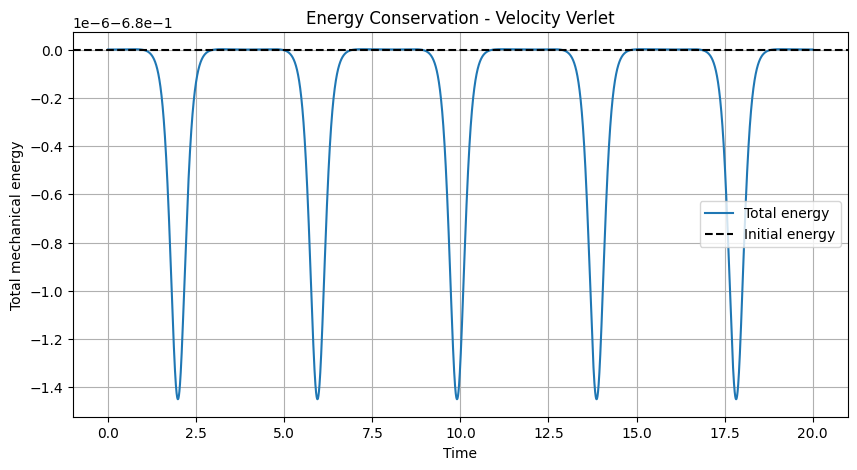

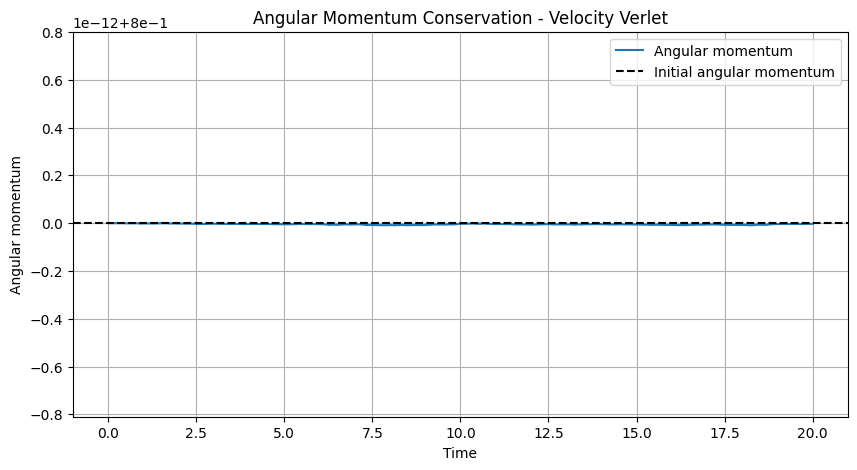

PART A - CONSERVATION RESULTS
-------------------------------------------------------
Initial energy: -0.68000000
Final energy:   -0.68000000
Maximum fractional energy error: 2.131864e-06

Initial angular momentum: 0.80000000
Final angular momentum:   0.80000000
Maximum fractional angular momentum error: 1.179612e-14

Initial acceleration: [-1. -0.]
Circular speed at r = 1: 1.0000


In [5]:
# PART A - A SINGLE ORBIT WITH VELOCITY VERLET

# A1. GRAVITATIONAL ACCELERATION FUNCTION

def accel(r):
    """Calculate gravitational acceleration toward the central star."""

    dist = np.linalg.norm(r)

    return -G * M * r / dist**3

# A2. VELOCITY VERLET INTEGRATOR

def verlet_step(r, v, a, dt, accel_func):
    """Perform one Velocity Verlet integration step."""

    # Update position
    r_new = r + v * dt + 0.5 * a * dt**2

    # Calculate acceleration at the new position
    a_new = accel_func(r_new)

    # Update velocity
    v_new = v + 0.5 * (a + a_new) * dt

    return r_new, v_new, a_new

# A3. ENERGY AND ANGULAR MOMENTUM FUNCTIONS

def energy(r, v, G=1.0, M=1.0, m=1.0):
    """Calculate total mechanical energy."""

    ke = 0.5 * m * np.dot(v, v)

    pe = -G * M * m / np.linalg.norm(r)

    return ke + pe

def ang_momentum(r, v, m=1.0):
    """Calculate angular momentum in two dimensions."""

    return m * (r[0] * v[1] - r[1] * v[0])

# A4. INITIAL CONDITIONS

r0 = np.array([1.0, 0.0])
v0 = np.array([0.0, 0.8])

r = r0.copy()
v = v0.copy()
a = accel(r)

dt = 0.001
n_steps = 20000

# Store the initial conditions
rs = [r.copy()]
vs = [v.copy()]

energies = [energy(r, v)]
angular_momenta = [ang_momentum(r, v)]

# A5. ORBITAL SIMULATION

for _ in range(n_steps):

    # Advance the simulation by one step
    r, v, a = verlet_step(r, v, a, dt, accel)

    # Store position and velocity
    rs.append(r.copy())
    vs.append(v.copy())

    # Track conserved quantities
    energies.append(energy(r, v))
    angular_momenta.append(ang_momentum(r, v))

# Convert lists into NumPy arrays
rs = np.array(rs)
vs = np.array(vs)

energies = np.array(energies)
angular_momenta = np.array(angular_momenta)

times = np.arange(n_steps + 1) * dt

# A6. ORBITAL TRAJECTORY

plt.figure(figsize=(8, 8))

plt.plot(
    rs[:, 0],
    rs[:, 1],
    label="Planet trajectory"
)

plt.scatter(
    0, 0,
    color="orange",
    s=150,
    label="Central star",
    zorder=5
)

plt.scatter(
    r0[0],
    r0[1],
    color="red",
    s=50,
    label="Initial position",
    zorder=5
)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Elliptical Orbit Using Velocity Verlet")

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# A7. ENERGY CONSERVATION

plt.figure(figsize=(10, 5))

plt.plot(times, energies, label="Total energy")

plt.axhline(
    energies[0],
    color="black",
    linestyle="--",
    label="Initial energy"
)

plt.xlabel("Time")
plt.ylabel("Total mechanical energy")
plt.title("Energy Conservation - Velocity Verlet")

plt.grid(True)
plt.legend()
plt.show()

# A8. ANGULAR MOMENTUM CONSERVATION

plt.figure(figsize=(10, 5))

plt.plot(
    times,
    angular_momenta,
    label="Angular momentum"
)

plt.axhline(
    angular_momenta[0],
    color="black",
    linestyle="--",
    label="Initial angular momentum"
)

plt.xlabel("Time")
plt.ylabel("Angular momentum")
plt.title("Angular Momentum Conservation - Velocity Verlet")

plt.grid(True)
plt.legend()
plt.show()

# A9. CONSERVATION ERROR ANALYSIS

energy_error = np.abs(
    (energies - energies[0]) / energies[0]
)

angular_momentum_error = np.abs(
    (angular_momenta - angular_momenta[0])
    / angular_momenta[0]
)

print("PART A - CONSERVATION RESULTS")
print("-" * 55)

print(f"Initial energy: {energies[0]:.8f}")
print(f"Final energy:   {energies[-1]:.8f}")

print(
    f"Maximum fractional energy error: "
    f"{np.max(energy_error):.6e}"
)

print()

print(
    f"Initial angular momentum: "
    f"{angular_momenta[0]:.8f}"
)

print(
    f"Final angular momentum:   "
    f"{angular_momenta[-1]:.8f}"
)

print(
    f"Maximum fractional angular momentum error: "
    f"{np.max(angular_momentum_error):.6e}"
)

print()

print(f"Initial acceleration: {accel(r0)}")
print(f"Circular speed at r = 1: {np.sqrt(G * M):.4f}")

## Part A - Intrepretation

The initial position of the planet is apoaspsis (the point furthest from the central star). With an initial radius of 1.0, the circular orbital speed is set to 1.0. Given that the planet begins with a tangential velocity of 0.8, it moves too slowly to maintain a circular orbit, and as a result, begins moving inward toward the star.

The orbital trajectory from the simulation demonstrates the expected elliptical motion, with the central star resting at one focus of said ellipse. The planet itself completes multiple orbits while still maintaining an approximately closed trajectory, without any spiraling.

The inital total mechanical energy was -0.68000000, the final ernergy was also found to be -0.68000000. However, the maximum fractional energy error still produced 2.131864e-06, which corresponds to approximately 0.000213% of the systems total mechanical energy. Furthermore, the energy in the graph shows relatively small periodic fluctionations rather than a continous increase or decrease. This demonstrates that the Velocity Verlet maintains a stable orbit across the entire simulation.

To that end, the initial and final angular momentum remained approximately constant throughout the simulation, resting at 0.80000000. The maximum fractional angular momentum error was found to be 1.17962e-14, which indicates that the angular momentum was conserved within floating-point precision.

Overall, the results help demonstrate how Velocity Verlet successfully reproduces a stable elliptical orbit whilst maintaing both energy and angular momentum (to a very high degree of accuracy).Though the method does not conserve the "exact" mechanical energy at each time step, the bounded fluctations prevent any long-term numerical drifts.

## Part B - The Integrator Showdown

In this part, we compare three numerical integration techniques with one another: Euler, Euler-Cromer, and Velocity Verlet.

Utilizing the same initial conditions, gravitational acceleration function, time step, and simulation duration, we are able to simulate a planet's orbit for each method used. This ultimately allows us to isolate the effects of numerical integration onto the stability of orbit and the system's energy conservation.

We then generate plots and compare the collected data for each method, in order to evaluate their individual accuracies.

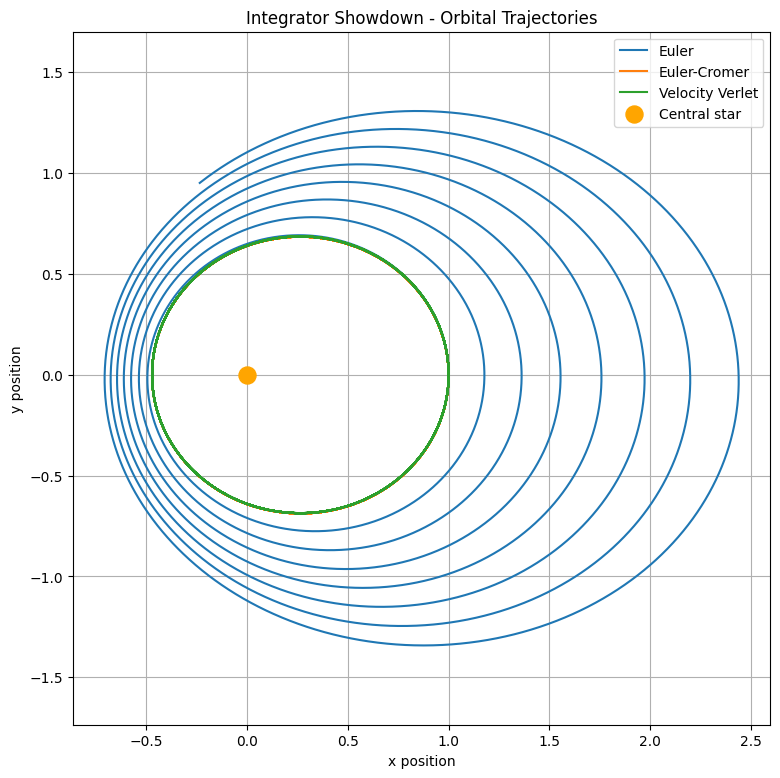

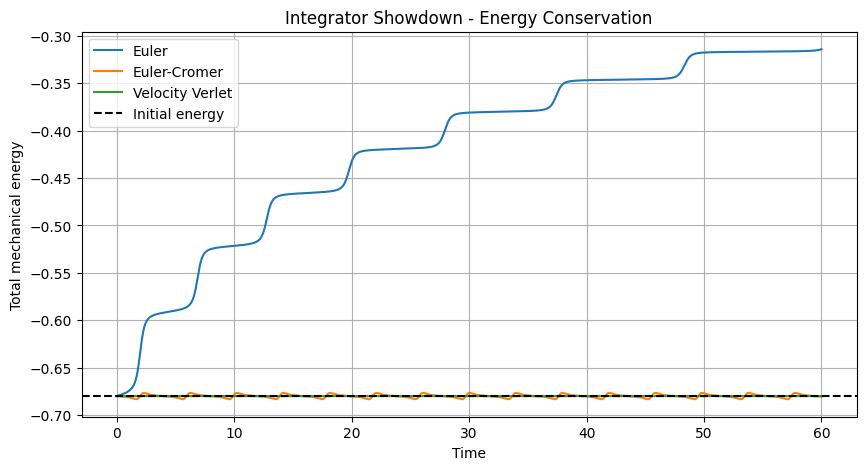

INTEGRATOR ENERGY ERROR SUMMARY
-------------------------------------------------------
Method               |  Maximum fractional error
-------------------------------------------------------
Euler                |              5.381464e-01
Euler-Cromer         |              4.913010e-03
Velocity Verlet      |              5.328643e-05
-------------------------------------------------------


In [ ]:

# PART B - THE INTEGRATOR SHOWDOWN

# B1. UNIFIED SIMULATION FUNCTION

def simulate(method, dt, n_steps):
    """
    Simulate an orbit using Euler, Euler-Cromer,
    or Velocity Verlet.
    """

    # Initial conditions
    r = r0.copy()
    v = v0.copy()
    a = accel(r)

    # Storage
    positions = [r.copy()]
    velocities = [v.copy()]
    total_energies = [energy(r, v)]

    # Main simulation loop
    for _ in range(n_steps):

        if method == "euler":

            # Update position using current velocity
            r_new = r + v * dt

            # Update velocity using current acceleration
            v_new = v + a * dt

            # Calculate acceleration at new position
            a_new = accel(r_new)

        elif method == "euler-cromer":

            # Update velocity first
            v_new = v + a * dt

            # Update position using new velocity
            r_new = r + v_new * dt

            # Calculate acceleration at new position
            a_new = accel(r_new)

        elif method == "verlet":

            # Perform one Velocity Verlet step
            r_new, v_new, a_new = verlet_step(
                r, v, a, dt, accel
            )

        else:

            raise ValueError("Unknown integration method.")

        # Update state
        r = r_new
        v = v_new
        a = a_new

        # Store results
        positions.append(r.copy())
        velocities.append(v.copy())
        total_energies.append(energy(r, v))

    return (
        np.array(positions),
        np.array(velocities),
        np.array(total_energies)
    )

# B2. SIMULATION PARAMETERS

dt_B = 0.005
n_steps_B = 12000

times_B = np.arange(n_steps_B + 1) * dt_B

# B3. RUN ALL THREE INTEGRATORS

rs_euler, vs_euler, E_euler = simulate(
    "euler", dt_B, n_steps_B
)

rs_cromer, vs_cromer, E_cromer = simulate(
    "euler-cromer", dt_B, n_steps_B
)

rs_verlet, vs_verlet, E_verlet = simulate(
    "verlet", dt_B, n_steps_B
)

# B4. ORBITAL TRAJECTORY COMPARISON

plt.figure(figsize=(9, 9))

plt.plot(
    rs_euler[:, 0],
    rs_euler[:, 1],
    label="Euler"
)

plt.plot(
    rs_cromer[:, 0],
    rs_cromer[:, 1],
    label="Euler-Cromer"
)

plt.plot(
    rs_verlet[:, 0],
    rs_verlet[:, 1],
    label="Velocity Verlet"
)

# Mark the central star
plt.scatter(
    0, 0,
    color="orange",
    s=150,
    label="Central star",
    zorder=5
)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Integrator Showdown - Orbital Trajectories")

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# B5. ENERGY CONSERVATION COMPARISON

plt.figure(figsize=(10, 5))

plt.plot(
    times_B,
    E_euler,
    label="Euler"
)

plt.plot(
    times_B,
    E_cromer,
    label="Euler-Cromer"
)

plt.plot(
    times_B,
    E_verlet,
    label="Velocity Verlet"
)

# Initial energy reference
plt.axhline(
    E_verlet[0],
    color="black",
    linestyle="--",
    label="Initial energy"
)

plt.xlabel("Time")
plt.ylabel("Total mechanical energy")
plt.title("Integrator Showdown - Energy Conservation")

plt.grid(True)
plt.legend()
plt.show()

# B6. MAXIMUM FRACTIONAL ENERGY ERROR

def max_fractional_energy_error(E):
    """Calculate the maximum fractional energy error."""

    E0 = E[0]

    return np.max(np.abs((E - E0) / E0))

# Calculate energy errors
error_euler = max_fractional_energy_error(E_euler)

error_cromer = max_fractional_energy_error(E_cromer)

error_verlet = max_fractional_energy_error(E_verlet)

# B7. ENERGY ERROR SUMMARY TABLE

print("INTEGRATOR ENERGY ERROR SUMMARY")
print("-" * 55)

print(
    f"{'Method':<20} | "
    f"{'Maximum fractional error':>25}"
)

print("-" * 55)

print(
    f"{'Euler':<20} | "
    f"{error_euler:>25.6e}"
)

print(
    f"{'Euler-Cromer':<20} | "
    f"{error_cromer:>25.6e}"
)

print(
    f"{'Velocity Verlet':<20} | "
    f"{error_verlet:>25.6e}"
)

print("-" * 55)